# Benchmark data: Krueger (2012), NASA/CR-2012-217562

R. Krueger, *Development and Application of Benchmark Examples for Mixed-Mode I/II Quasi-Static Delamination Propagation Predictions*, NASA/CR-2012-217562, NIA Report No. 2012-01, 2012.

**This report contains no DCB case.** Its benchmarks are for the mixed-mode bending (MMB) specimen at $G_{II}/G_T$ = 0.2, 0.5 and 0.8, created with 2D plane strain FE models and the virtual crack closure technique (VCCT), and used to assess the VCCT propagation of ABAQUS. The DCB benchmark of the same series is in R. Krueger, *An Approach to Assess Delamination Propagation Simulation Capabilities in Commercial Finite Element Codes*, NASA/TM-2008-215123 (reference [3] of the report), which is not included here.

The DCB dictionaries below are therefore empty. The MMB data are recorded in `mmb_cases` for a future comparison. panels cannot be run on these cases yet:

- the damage of the `SB_TSL` connection is driven by the normal separation only, while the MMB needs a mixed-mode law, e.g. the Benzeggagh-Kenane criterion with $\eta = 2.1$ used in the report;
- the loading lever of the MMB apparatus is not modelled.

**Digitised data.** The benchmark curves of Figs. 10, 14 and 19 were read by eye, $\pm 0.1$ mm and $\pm 3$% of the load. The critical points $(w_{crit}, P_{crit})$ are given in the text and are exact.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, os.path.abspath('.'))
import dcb_utils as du

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'


## DCB cases

In [2]:
fe_cases = {}   # no DCB case in NASA/CR-2012-217562
exp_tests = {}  # no DCB load-displacement data in NASA/CR-2012-217562


## MMB benchmark data

In [3]:
im7_8552 = dict(E11=161000., E22=11380., E33=11380., nu12=0.32, nu13=0.32, nu23=0.45,
                G12=5200., G13=5200., G23=3900.,
                GIc=0.212, GIIc=0.774, eta_BK=2.1)
mmb_geometry = dict(b=25.4, h_total=4.5, L2=100.8, L2_star=152.4, a0=25.4, layup='[0]24')

mmb_cases = {
    'MMB_GII_GT_0.2': dict(im7_8552, **mmb_geometry, c=92.9, wcrit=1.64, Pcrit=128.5,
        source='Figs. 3, 9, 10',
        benchmark=(np.array([0, 1.64, 1.8, 2.2, 2.55, 3.0, 3.3, 3.6, 4.0, 4.7, 5.6, 6.5, 7.4, 8.4, 9.0]),
                   np.array([0, 128.5, 114., 96., 85., 76., 73., 73.5, 76., 79., 81.5, 85., 88., 91.5, 94.]))),
    'MMB_GII_GT_0.5': dict(im7_8552, **mmb_geometry, c=41.3, wcrit=1.34, Pcrit=385.,
        source='Figs. 4a, 13, 14 (benchmark for applied displacement)',
        benchmark=(np.array([0, 1.34, 1.45, 1.6, 1.8, 1.95, 2.2, 2.5, 3.3, 4.4, 6.0, 7.7]),
                   np.array([0, 385., 290., 255., 225., 218., 232., 255., 297., 365., 467., 600.]))),
    'MMB_GII_GT_0.8': dict(im7_8552, **mmb_geometry, c=27.3, wcrit=1.65, Pcrit=751.,
        source='Figs. 4b, 18, 19 (benchmark for applied displacement)',
        benchmark=(np.array([0, 1.65, 1.7, 1.8, 1.95, 2.2, 2.5, 3.2, 4.1, 5.0, 6.0, 6.8]),
                   np.array([0, 751., 480., 430., 418., 445., 485., 575., 665., 765., 895., 1000.]))),
}


## Table and plot of the benchmark data

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) |
|---|---|---|---|
| MMB_GII_GT_0.2 | 78.35 | 128.5 | 1.64 |
| MMB_GII_GT_0.5 | 287.31 | 385.0 | 1.34 |
| MMB_GII_GT_0.8 | 455.15 | 751.0 | 1.65 |

| case | $w_{crit}$ (mm) | $P_{crit}$ (N) | lever $c$ (mm) |
|---|---|---|---|
| MMB_GII_GT_0.2 | 1.64 | 128.5 | 92.9 |
| MMB_GII_GT_0.5 | 1.34 | 385.0 | 41.3 |
| MMB_GII_GT_0.8 | 1.65 | 751.0 | 27.3 |

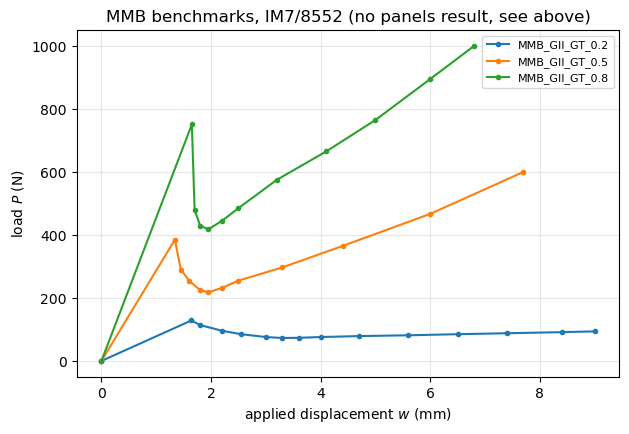

In [4]:
rows = {k: v['benchmark'] for k, v in mmb_cases.items()}
display(Markdown(du.markdown_table(rows, first_peak=True)))
display(Markdown('| case | $w_{crit}$ (mm) | $P_{crit}$ (N) | lever $c$ (mm) |\n|---|---|---|---|\n' +
                 '\n'.join(f"| {k} | {v['wcrit']} | {v['Pcrit']} | {v['c']} |" for k, v in mmb_cases.items())))
fig, ax = plt.subplots(figsize=(7, 4.5))
du.plot_curves(ax, rows, {k: dict(marker='o', ms=3) for k in rows})
ax.set_xlabel('applied displacement $w$ (mm)')
ax.set_title('MMB benchmarks, IM7/8552 (no panels result, see above)')
plt.show()
